# Evalvaluate Predictions

In [3]:
%load_ext autoreload
%autoreload 2
import os
import polars as pl
import numpy as np
from deeptan.utils.metrics import MetricsDictMaker

/home/wuch/miniforge3/envs/t1/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Computing metrics

In [4]:
path_home_deeptan = "/mnt/hdd2/homext/wuch/xn2p"
path_predictions = os.path.join(path_home_deeptan, "run", "predict", "deeptan")
path_raw_df = os.path.join(path_home_deeptan, "data", "raw_df")

### scmul (balanced)

In [5]:
dataset = "scmul_mi035_top2000"
path_true = os.path.join(path_raw_df, "scMultiome", "Ath_scMultiome_WT_split_full")
path_orig_h5ad = os.path.join(path_true, "origin.h5ad")

metricsmaker = MetricsDictMaker(os.path.join(path_predictions, dataset), path_true, True, path_orig_h5ad)
metricsmaker.load_predictions()
metricsmaker.load_true()


Found file📄 preds+seed_42+multitask+tst.h5 with task🎯 multitask and split🍰 tst.
Found file📄 preds+seed_42+multitask+trn.h5 with task🎯 multitask and split🍰 trn.
Found file📄 preds+seed_42+multitask+val.h5 with task🎯 multitask and split🍰 val.


In [15]:
obs_names_pred = metricsmaker._read_batch_in_h5(metricsmaker.fnames[0], "obs_name")
obs_names_pred_list = [i.decode('utf-8') for i in obs_names_pred]
print(len(obs_names_pred_list))
print(obs_names_pred_list)

564
['CK_ATGAAGCCACATGCTA-1', 'CK_CACCAACCAGGCTACT-1', 'CK_ATCCATAAGGCTTAGT-1', 'CK_GTCCTCCCAATGCCCG-1', 'AT-CK_TTACGTTTCTAAATCG-1', 'CK_GGTTTCCTCCACCTTA-1', 'AT-CK_CTCTATGTCCAGGGAG-1', 'CK_AATCTCAAGTAGCGCC-1', 'CK_TGACTTAAGGCGGGTA-1', 'CK_CGTTAGGTCGGTTTGG-1', 'CK_ACACCTTGTTTGGGCG-1', 'CK_TCTTAGTTCCCTCACG-1', 'CK_CAAGAACCATGAGCAG-1', 'AT-CK_AGACTATGTTTATCGC-1', 'CK_TGACTTAAGGCGCTTA-1', 'AT-CK_GAAACCCGTGATTACG-1', 'CK_TCCATGCTCGCGCTAA-1', 'CK_GTAGTTATCGTTTCGC-1', 'AT-CK_ATATAGGCAGAATGAC-1', 'AT-CK_CGAGTCGGTGATGGCT-1', 'AT-CK_CGGAGTCTCTACTAAG-1', 'CK_GCTAGCGGTCACACCC-1', 'CK_ACCCTGTTCAGCCAAT-1', 'CK_GATTAAGCAATATAGG-1', 'AT-CK_ACTATGTCACTAGCGT-1', 'CK_TTATAGCCACCGGCTA-1', 'CK_CCTCAATGTTCGGTAA-1', 'CK_CATTGCGAGCCGCTAA-1', 'CK_CACCTCAGTAACTACG-1', 'CK_GCAGGCTTCCGCCTCA-1', 'CK_GTCTATCGTTTCAGGA-1', 'CK_ACGCTTGAGCCTGATG-1', 'AT-CK_TGAAGTGAGTGAAGTG-1', 'AT-CK_TCAGCAAGTCTCACTG-1', 'CK_GGGTTTGTCTTGTCTG-1', 'CK_ATGACCAGTTACTTGC-1', 'AT-CK_TCACTGACACAGGGAC-1', 'CK_GATGCTTAGCCTCTCG-1', 'CK_ACCCAACC

In [16]:
if obs_names_pred_list == metricsmaker.metrics_dict["true"]["seed_42_tst"]["obs_names"]:
    print("list1 和 list2 的内容和顺序完全相同")
else:
    print("list1 和 list2 的内容和顺序不完全相同")

if sorted(obs_names_pred_list) == sorted(metricsmaker.metrics_dict["true"]["seed_42_tst"]["obs_names"]):
    print("list1 和 list2 的内容和顺序完全相同")
else:
    print("list1 和 list2 的内容和顺序不完全相同")

list1 和 list2 的内容和顺序不完全相同
list1 和 list2 的内容和顺序完全相同


### Write to CSV

In [6]:
# metricsmaker.metrics_dict["summary_recon"].write_csv(f"result.{dataset}.summary_recon.csv")
# metricsmaker.metrics_dict["summary_label"].write_csv(f"result.{dataset}.summary_label.csv")
# metricsmaker.metrics_dict["summary_clustering"].write_csv(f"result.{dataset}.summary_clustering.csv")

## Plot

In [28]:
from deeptan.utils.metrics import pacmap_plot, pacmap_plot_data

%config InlineBackend.figure_format = 'retina'
%config InlineBackend.figure_dpi = 300

### Plot PaCMAP

In [32]:
_seed = 42
_split = "tst"

_tasks = ["multitask"]
# _tasks_text = ["Multitask"]

In [33]:
true_features, pred_features, g_embs, y_true_text, ys_pred_text = pacmap_plot_data(metricsmaker, _tasks, _split, _seed)

print(true_features.shape)
print(g_embs["multitask"].shape)
print(pred_features["multitask"].shape)

Unique cell types:  ['Atrichoblast', 'Columella', 'Cortex', 'Dividing.cells', 'Endodermis', 'Epidermis', 'Initials', 'LRC', 'Phloem', 'QC', 'Stele', 'Suberin.endo', 'Trichoblast', 'XPP', 'Xylem', 'unknown']
(564, 5064)
(564, 384)
(564, 5064)


#### Now we can plot

/home/wuch/miniforge3/envs/t1/lib/python3.10/site-packages/legacy_api_wrap/__init__.py:82: UserWarning: `flavor='seurat_v3'` expects raw count data, but non-integers were found.
  return fn(*args_all, **kw)



Task: multitask


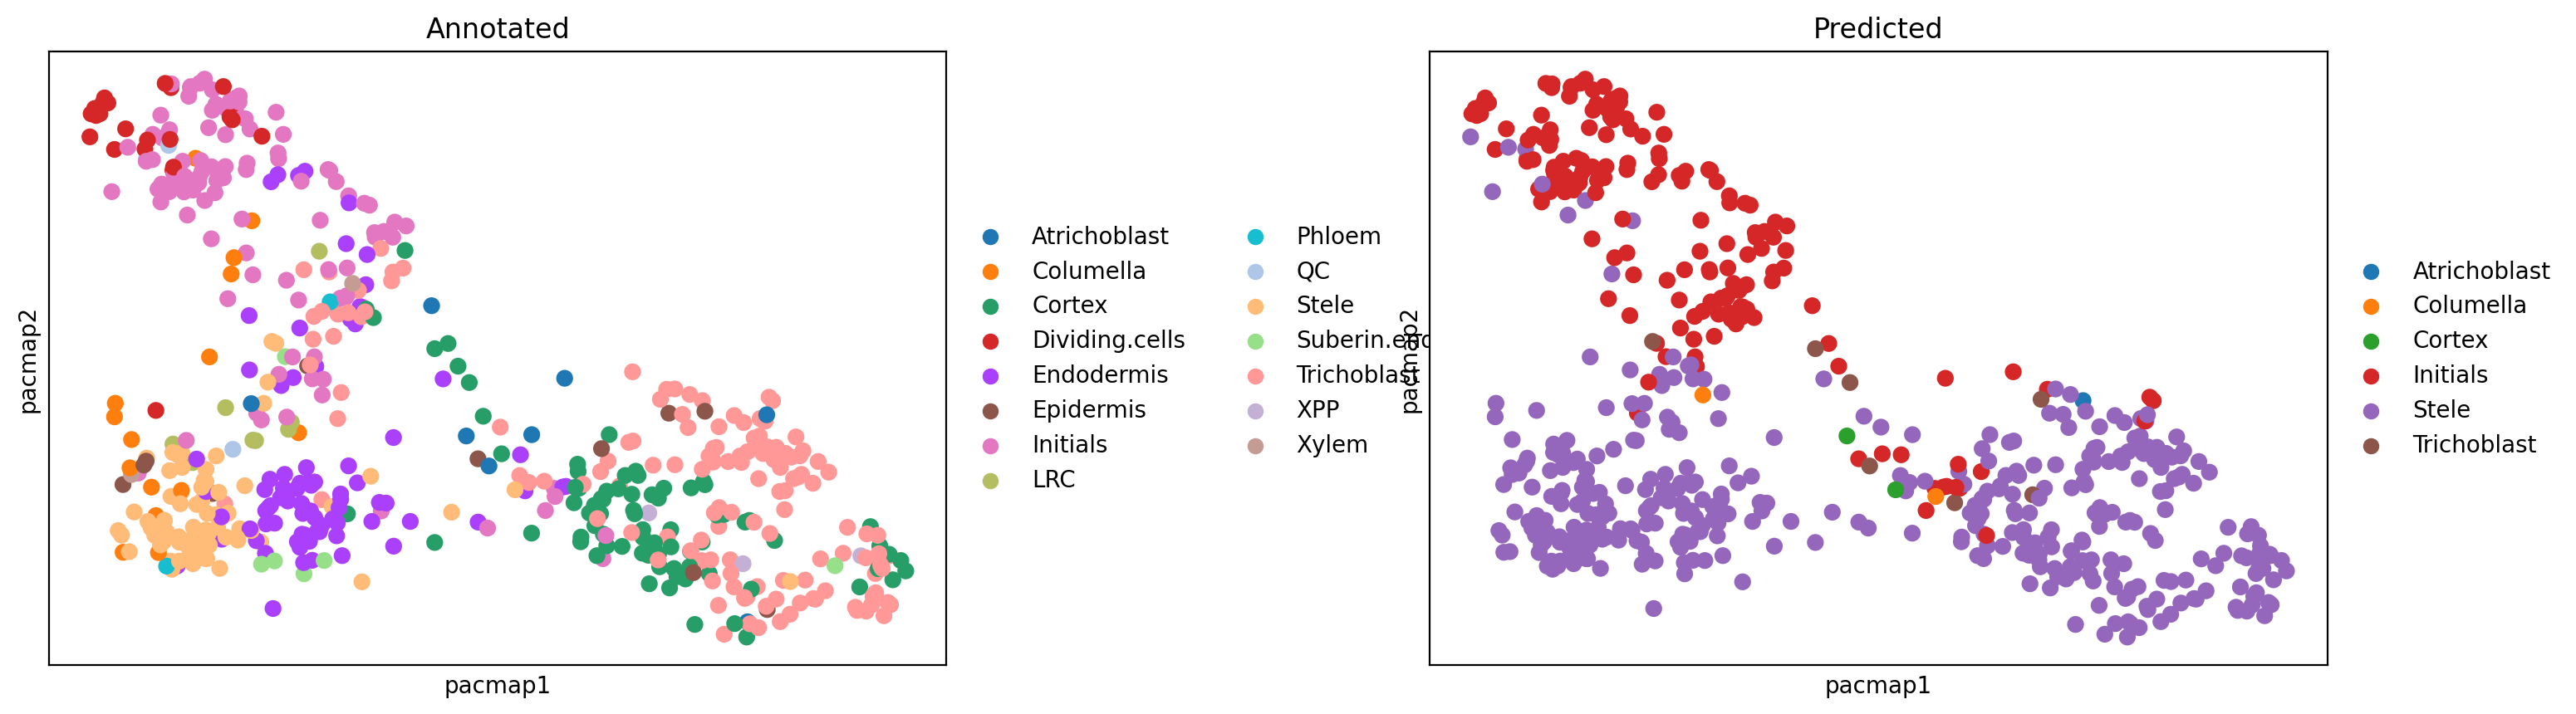

Input data contains invalid values (<= 0 or NaN).


/home/wuch/miniforge3/envs/t1/lib/python3.10/site-packages/legacy_api_wrap/__init__.py:82: UserWarning: `flavor='seurat_v3'` expects raw count data, but non-integers were found.
  return fn(*args_all, **kw)


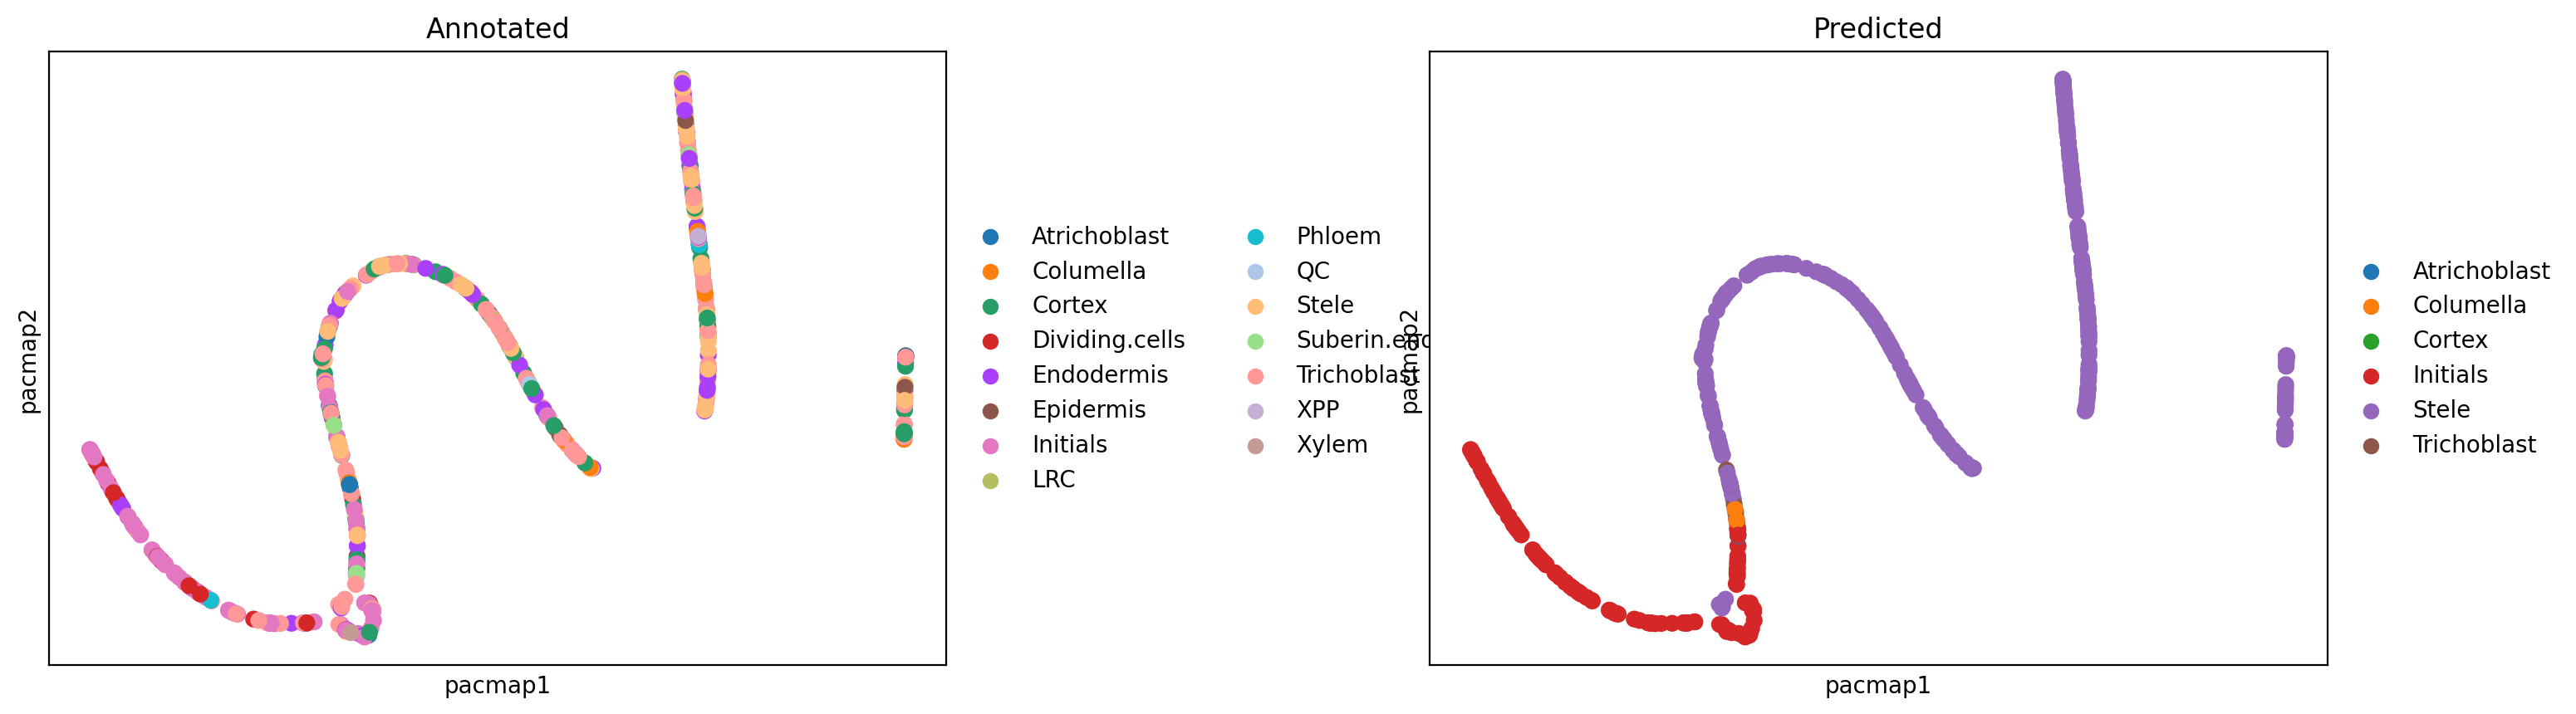

/home/wuch/miniforge3/envs/t1/lib/python3.10/site-packages/scipy/sparse/_index.py:210: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_arrayXarray(i, j, x)


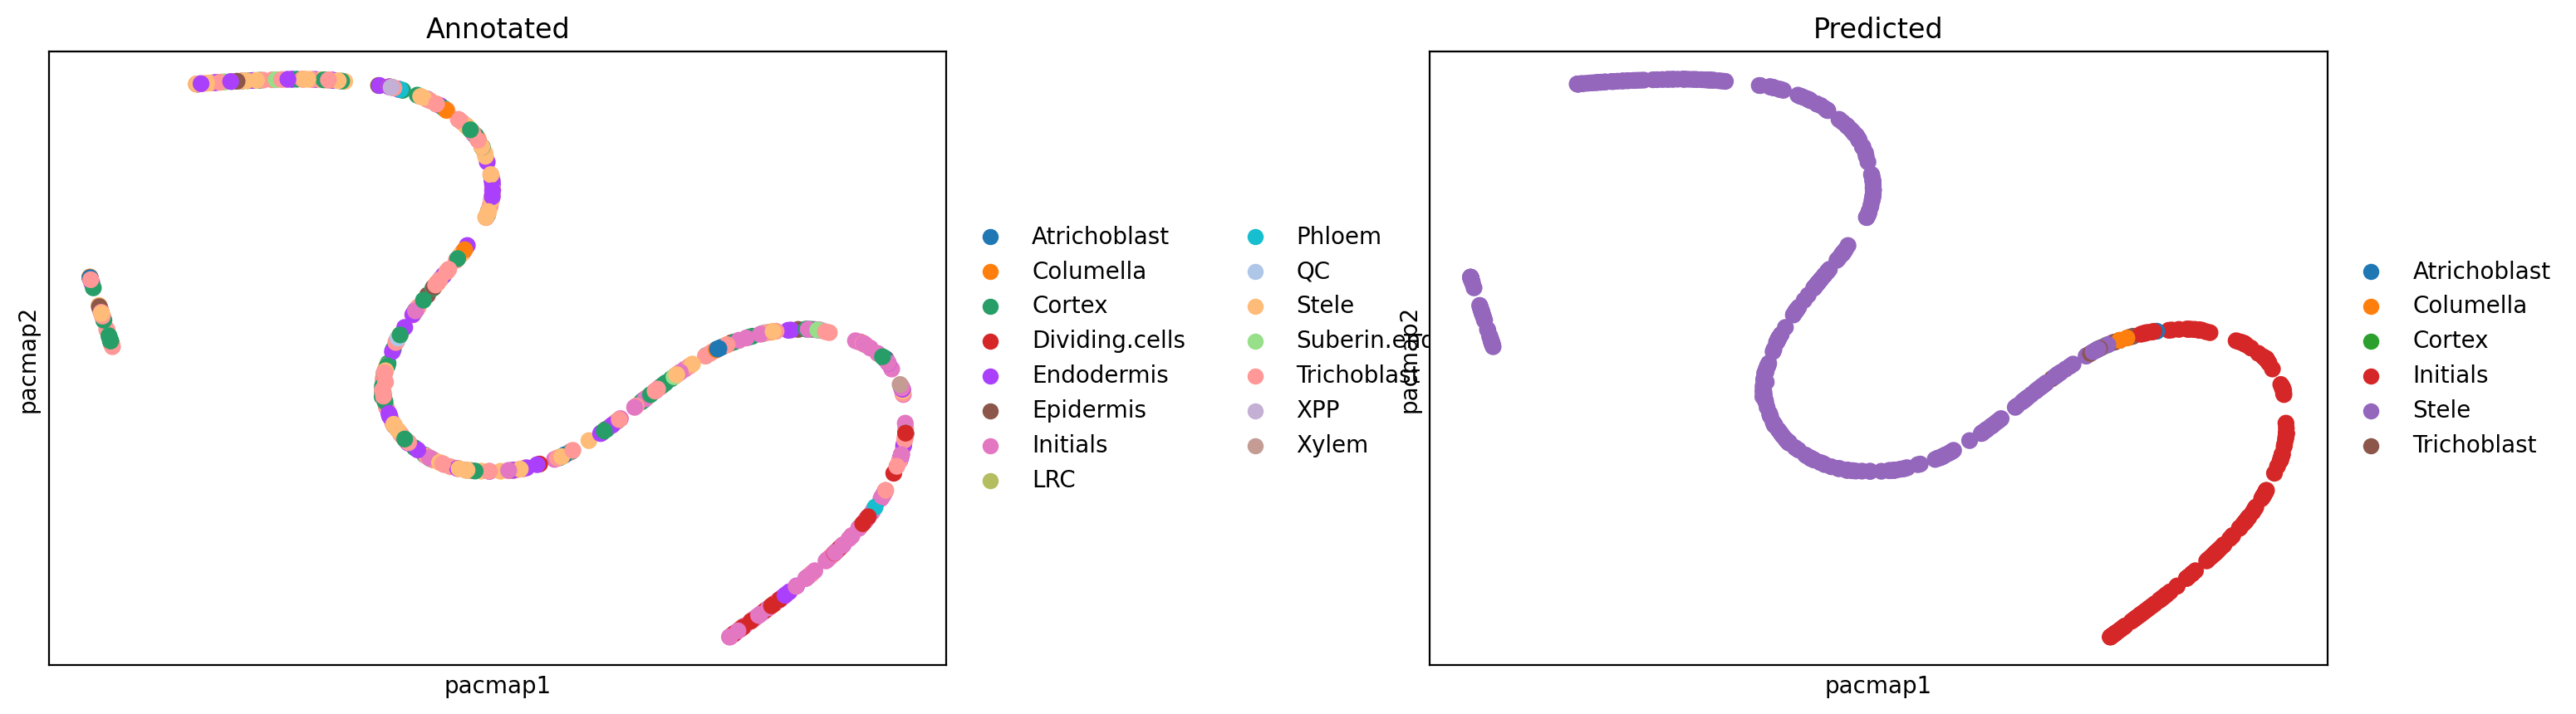

In [34]:
pacmap_plot(true_features, pred_features, g_embs, y_true_text, ys_pred_text)

Unique cell types:  ['Atrichoblast', 'Columella', 'Cortex', 'Dividing.cells', 'Endodermis', 'Epidermis', 'Initials', 'LRC', 'Phloem', 'QC', 'Stele', 'Suberin.endo', 'Trichoblast', 'XPP', 'Xylem', 'unknown']


/home/wuch/miniforge3/envs/t1/lib/python3.10/site-packages/legacy_api_wrap/__init__.py:82: UserWarning: `flavor='seurat_v3'` expects raw count data, but non-integers were found.
  return fn(*args_all, **kw)



Task: multitask


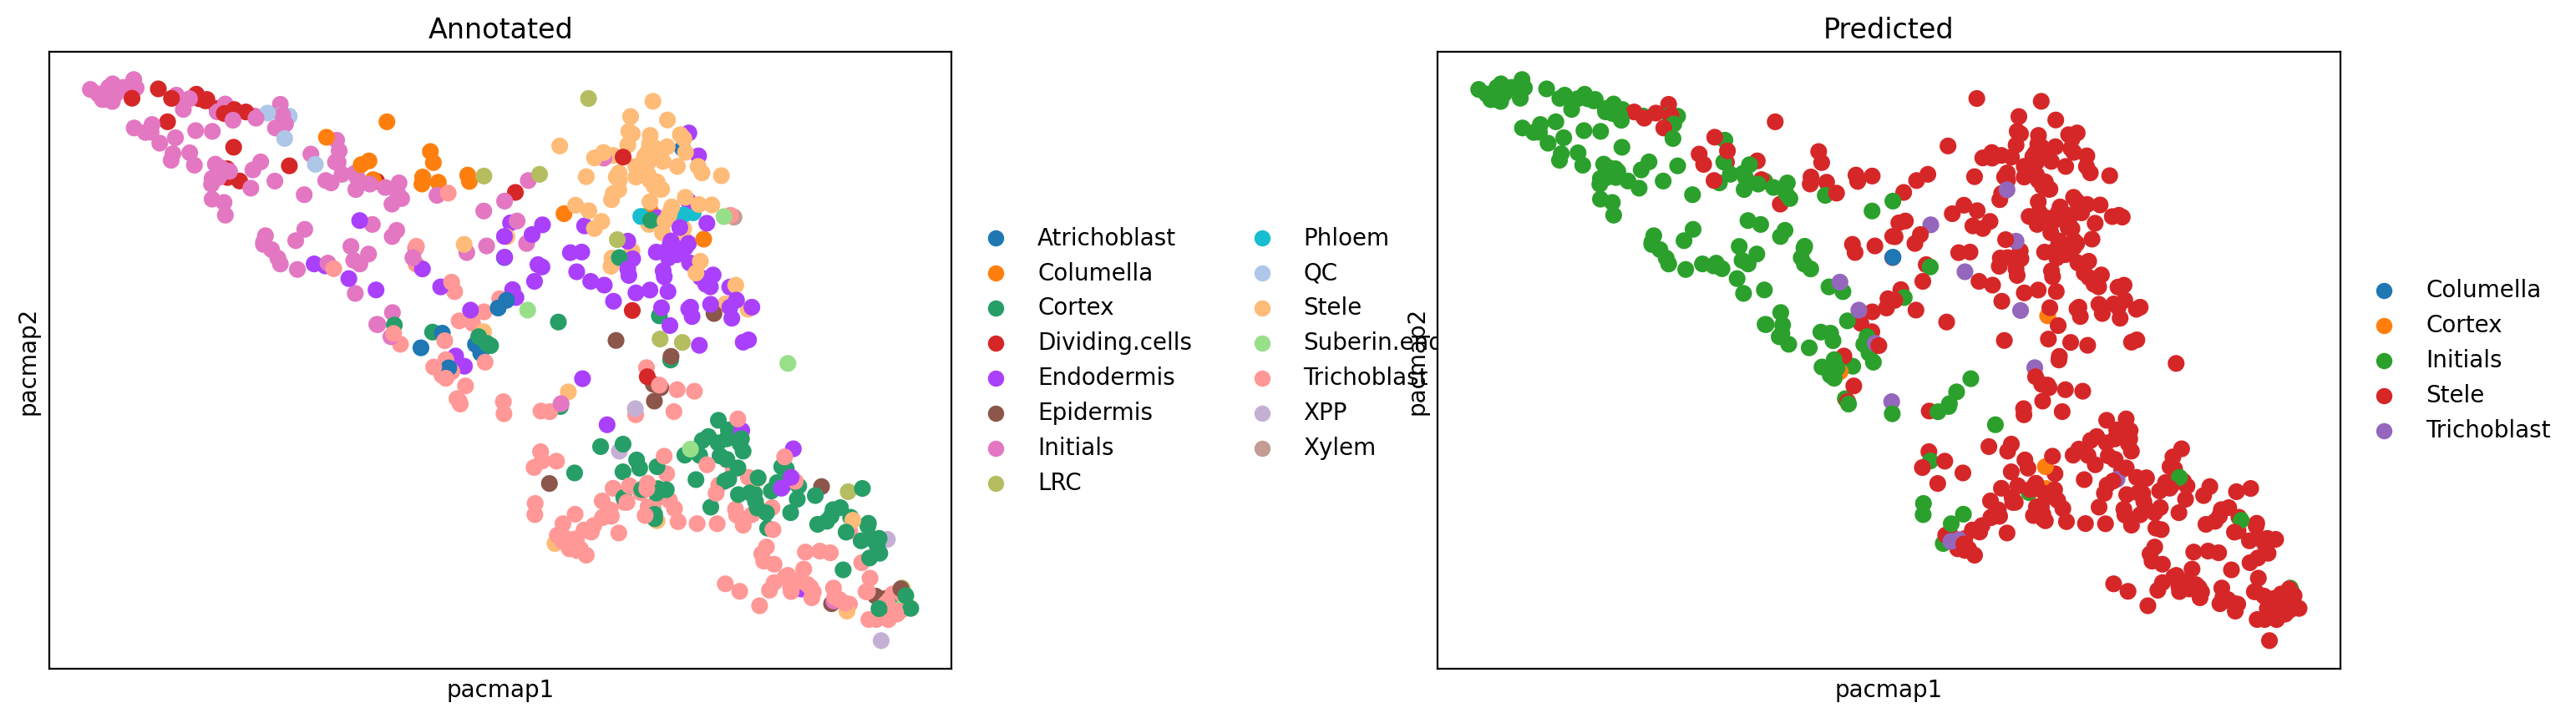

Input data contains invalid values (<= 0 or NaN).


/home/wuch/miniforge3/envs/t1/lib/python3.10/site-packages/legacy_api_wrap/__init__.py:82: UserWarning: `flavor='seurat_v3'` expects raw count data, but non-integers were found.
  return fn(*args_all, **kw)


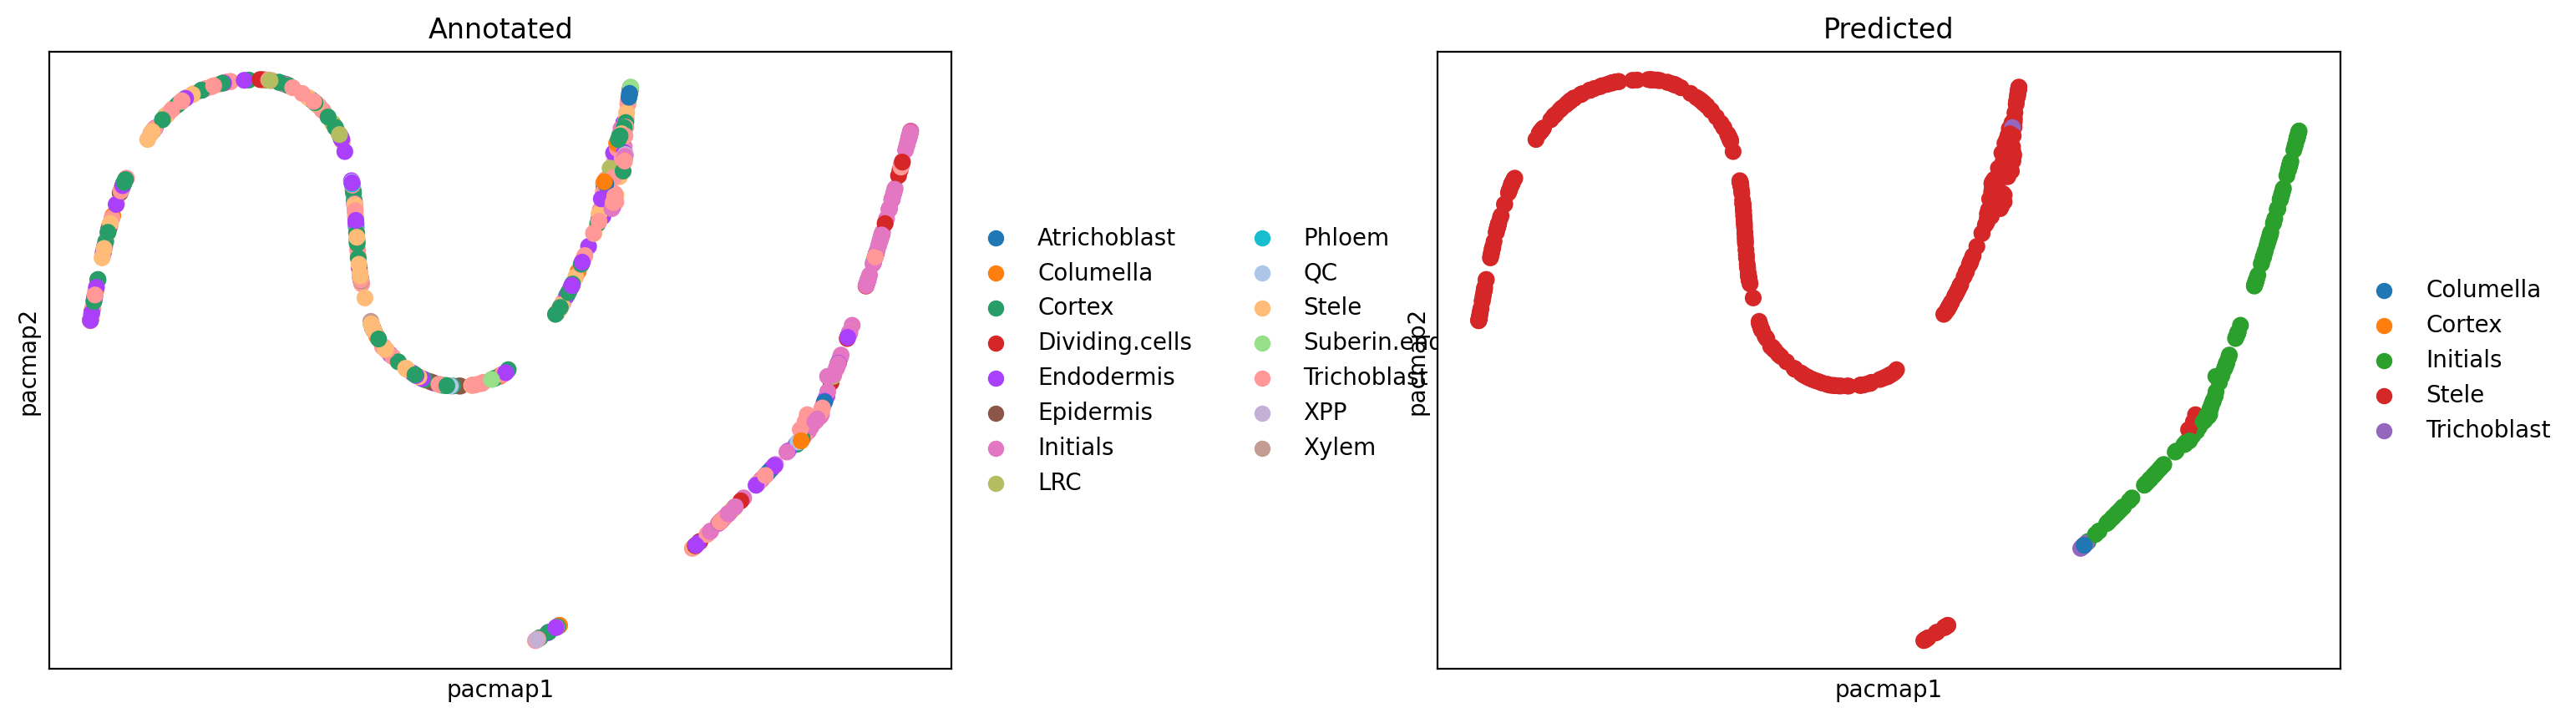

/home/wuch/miniforge3/envs/t1/lib/python3.10/site-packages/scipy/sparse/_index.py:210: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_arrayXarray(i, j, x)


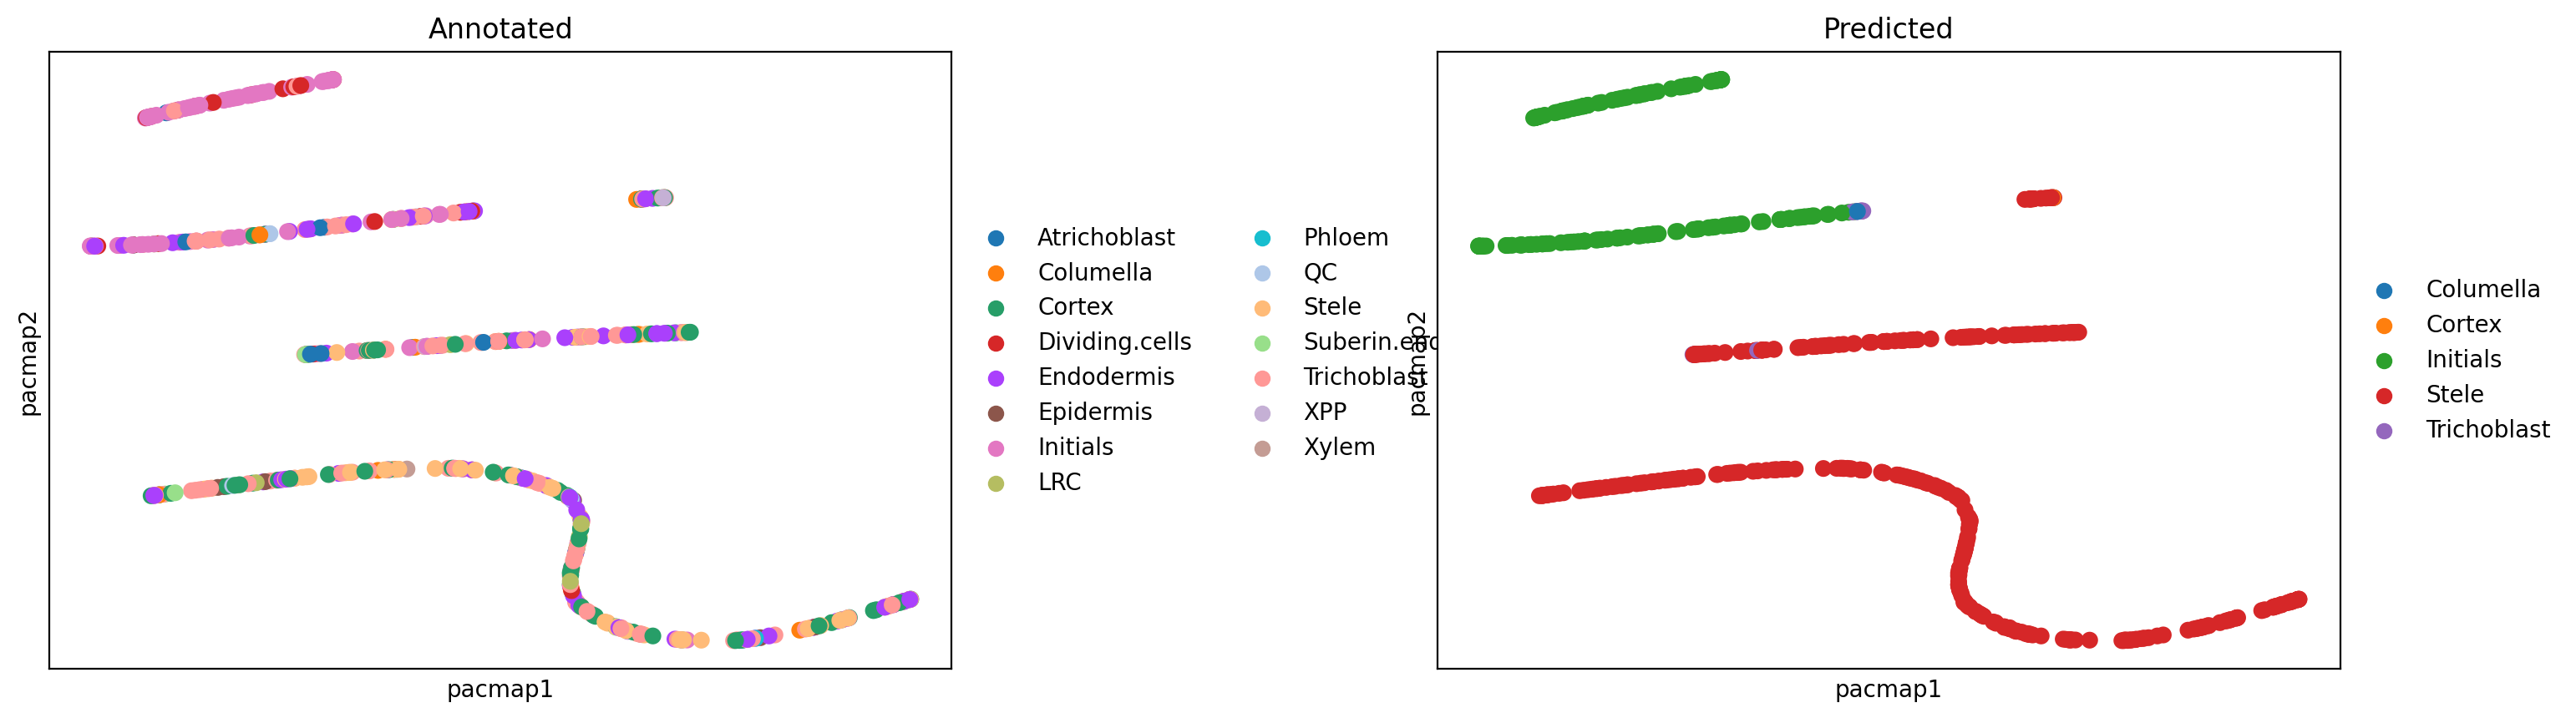

In [35]:
_seed = 42
_split = "val"
_tasks = ["multitask"]

pacmap_plot(*pacmap_plot_data(metricsmaker, _tasks, _split, _seed))

Unique cell types:  ['Atrichoblast', 'Columella', 'Cortex', 'Dividing.cells', 'Endodermis', 'Epidermis', 'Initials', 'LRC', 'Phloem', 'QC', 'Stele', 'Suberin.endo', 'Trichoblast', 'XPP', 'Xylem', 'unknown']


/home/wuch/miniforge3/envs/t1/lib/python3.10/site-packages/legacy_api_wrap/__init__.py:82: UserWarning: `flavor='seurat_v3'` expects raw count data, but non-integers were found.
  return fn(*args_all, **kw)



Task: multitask


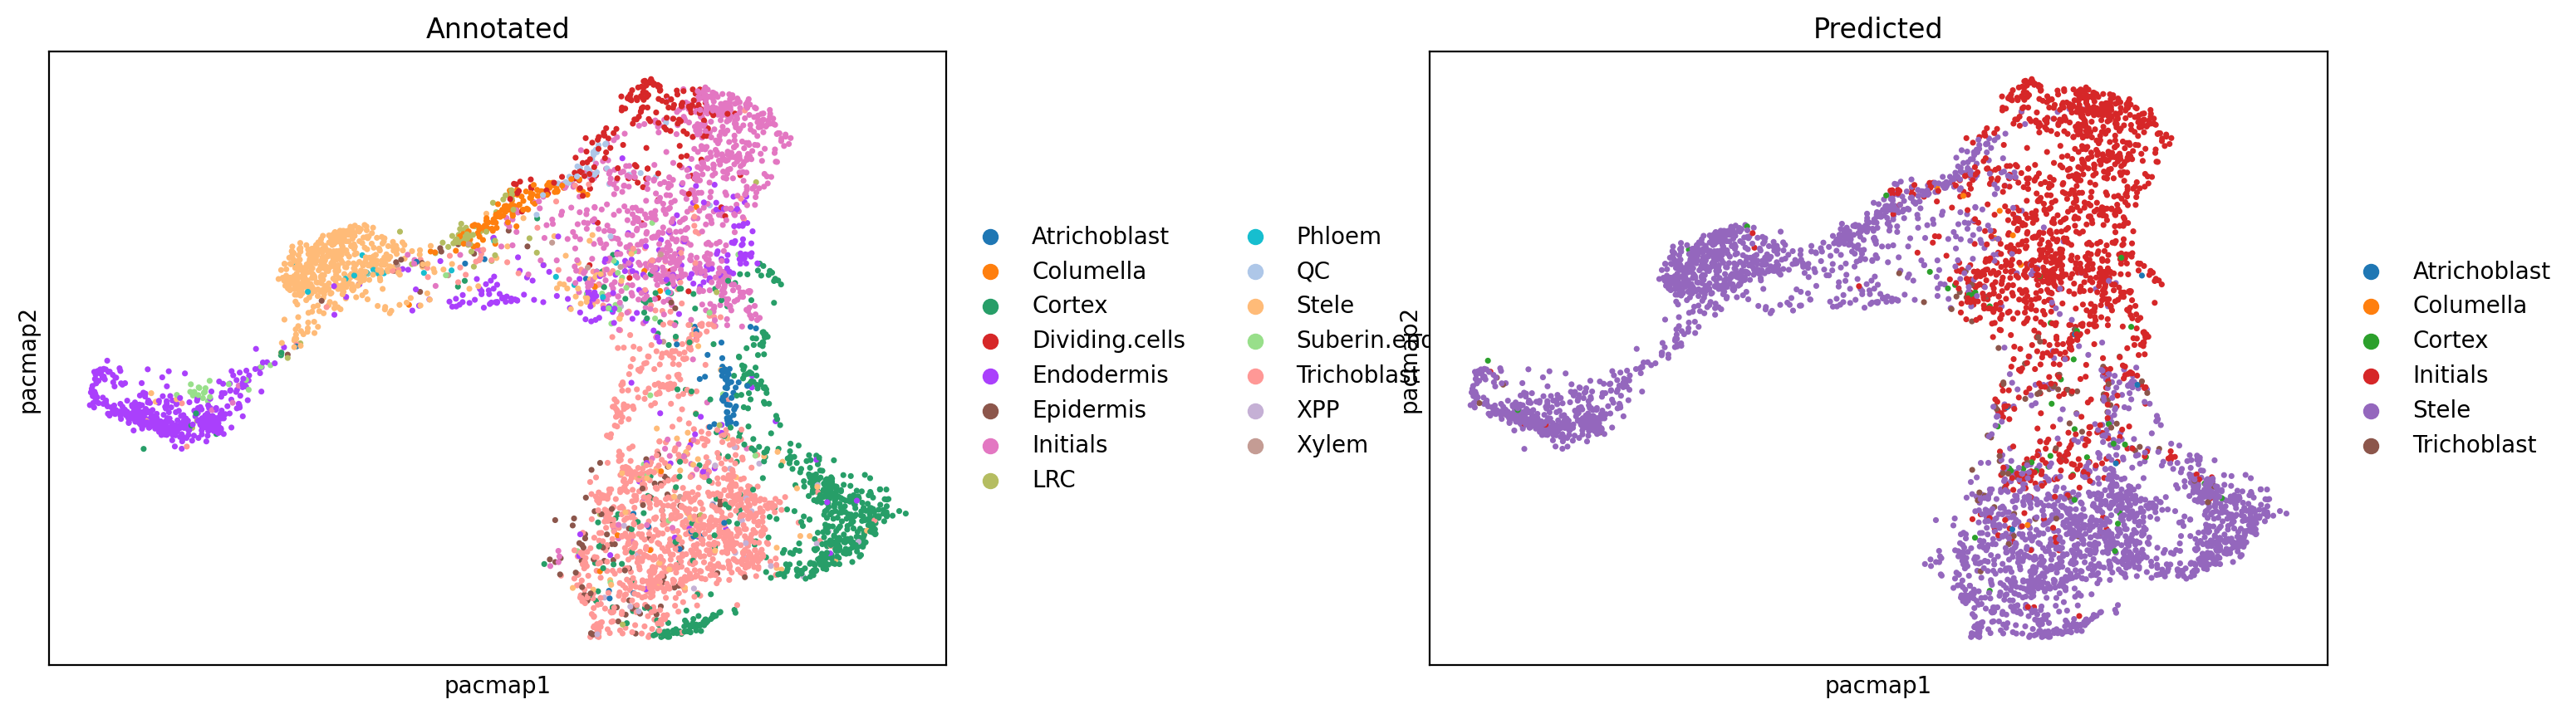

Input data contains invalid values (<= 0 or NaN).


/home/wuch/miniforge3/envs/t1/lib/python3.10/site-packages/legacy_api_wrap/__init__.py:82: UserWarning: `flavor='seurat_v3'` expects raw count data, but non-integers were found.
  return fn(*args_all, **kw)


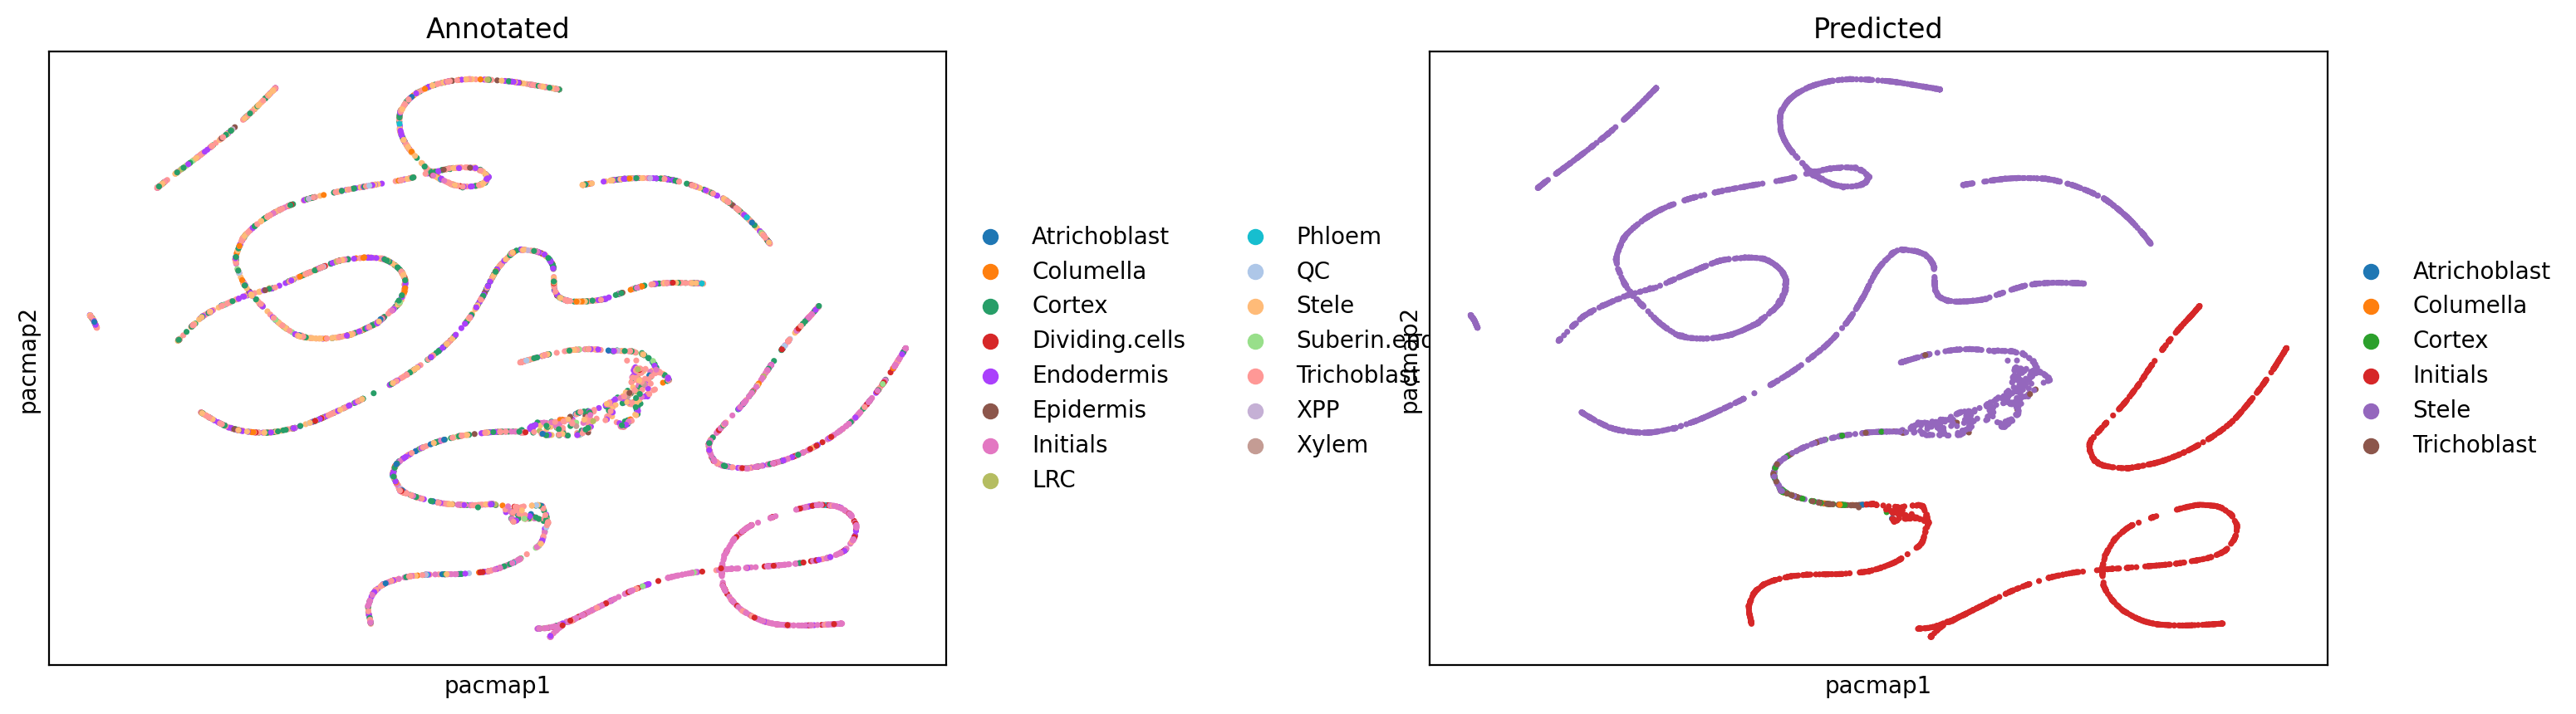

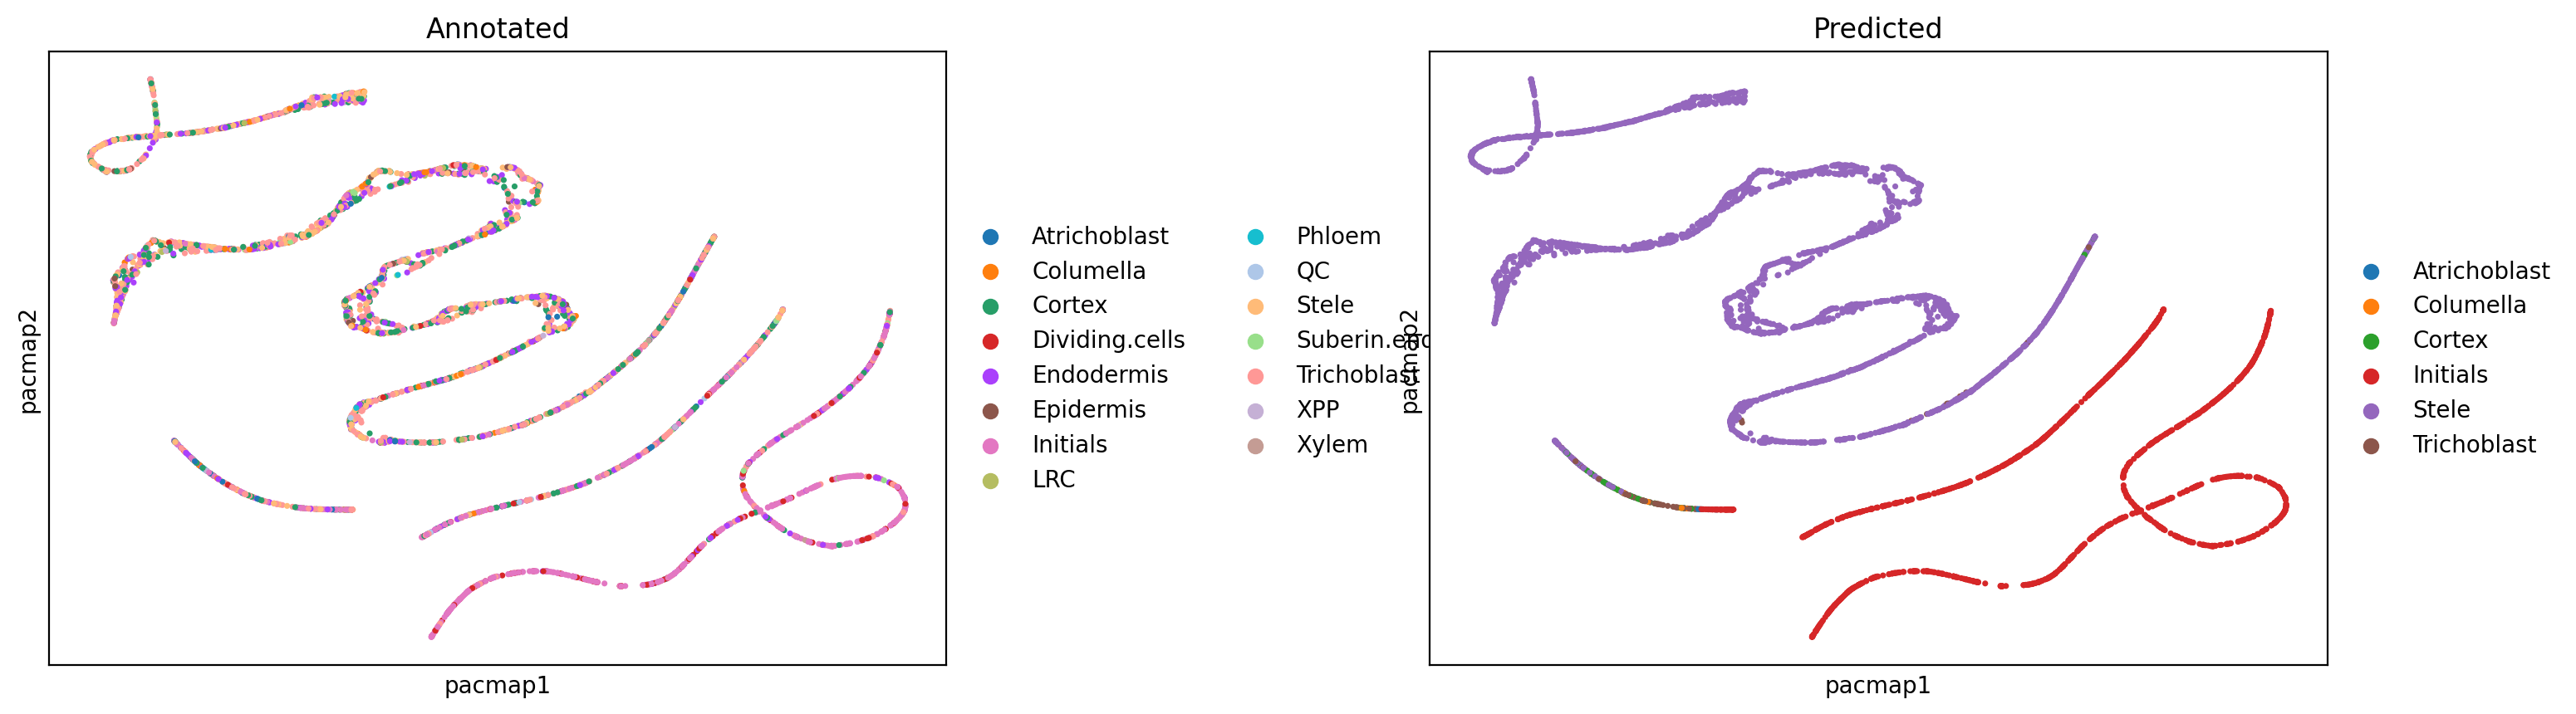

In [36]:
_seed = 42
_split = "trn"
_tasks = ["multitask"]

pacmap_plot(*pacmap_plot_data(metricsmaker, _tasks, _split, _seed))